## Gradient Boosting Regressor

### Importing pipelines and libraries

In [1]:
import sys
sys.path.append(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken")
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from src.data_loader import load_data
from src.preprocessing import clean_data
from src.feature_engineering import add_features
from src.pipelines import get_pipeline
from src.evalute import print_scores

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

### Loading train and test data sets

In [3]:
train_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\train.csv")
test_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\test.csv")

In [4]:
train_df = clean_data(train_df)
test_df = clean_data(test_df)

train_df = add_features(train_df)
test_df = add_features(test_df)

Column 'Time_taken(min)' not found in DataFrame!


### Defining Target feature and other features

In [5]:
target = "Time_taken(min)"

# Drop rows where target is missing
train_df = train_df.dropna(subset=[target])

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "distance_km",
    "order_to_pickup_time",
    "order_hour",
    "is_weekend"
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

X = train_df[numeric_features + categorical_features]
y = train_df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Fitting pipeline 

In [7]:
gbr = GradientBoostingRegressor(random_state=42)
gbr_pipeline = get_pipeline(gbr, numeric_features, categorical_features)


### Hyperparameter tuning using grid search cv

In [8]:
param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__learning_rate": [0.05, 0.1, 0.2],
    "regressor__max_depth": [3, 5],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=gbr_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)


In [9]:
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Delivery_person_Age',
                                                                          'Delivery_person_Ratings',
                                                                          'multiple_deliveries',
                                                                          'distance_km',
                                                                          'order_to_pickup_time',
                                                                          'order_hour',
                                                                          'is_weekend']),
                                                                        ('cat',
                                                                         Pipeline(steps=[(...
                                                                          'Road_traffic_density',
                                                                          'Type_of_order',
                                                                          'Type_of_vehicle',
                                                                          'Festival',
                                                                          'City'])])),
                                       ('regressor',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__learning_rate': [0.05, 0.1, 0.2],
                         'regressor__max_depth': [3, 5],
                         'regressor__min_samples_leaf': [1, 2],
                         'regressor__min_samples_split': [2, 5],
                         'regressor__n_estimators': [100, 200]},
             scoring='r2')

In [10]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best CV Score: 0.7596010341587746


### Evalute the model

In [11]:
best_model = grid.best_estimator_
print_scores(best_model, X_train, y_train, X_test, y_test)

Train MAE: 3.431915231093191
Test MAE: 3.609112579019313
Train MSE: 18.940123532673514
Test MSE: 21.094761580295597
Train R2: 0.7851316762937293
Test R2: 0.7594068217308864


### Graph visualization

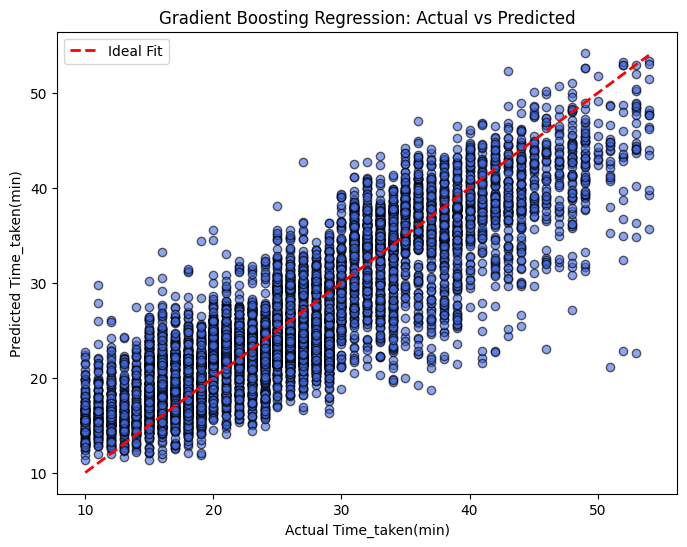

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on test set
y_pred = best_model.predict(X_test)

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Time_taken(min)')
plt.ylabel('Predicted Time_taken(min)')
plt.title('Gradient Boosting Regression: Actual vs Predicted')
plt.legend()